## Introduction

We will focus on Hawaii while exploring the shark attack data.


## Import the libraries

In [3]:
# For GeoPandas dataframes
!pip install geopandas

In [4]:
# For Geohashes
!pip install pygeohash

In [5]:
# For TargetEncoder to encode Geohashes
!pip install category_encoders

In [6]:
import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point
import pygeohash as pgh

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib

from sklearn import tree

from sklearn.compose import make_column_selector as col_selector
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder
from category_encoders import TargetEncoder


from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix

from sklearn.inspection import DecisionBoundaryDisplay

pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline 

## Setup Colors

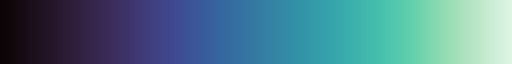

In [8]:
palette_str = 'mako'
palette_str_r = 'mako_r'
palette = sns.color_palette(palette_str)
palette_r = sns.color_palette(palette_str_r)
cmap = sns.color_palette(palette_str, as_cmap=True)
cmap_r = sns.color_palette(palette_str_r, as_cmap=True)
cmap


['#2e1e3b', '#413d7b', '#37659e', '#348fa7', '#40b7ad', '#8bdab2']


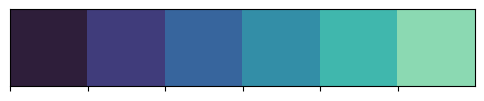

In [9]:
print(palette.as_hex())
sns.palplot(palette)
plt.show()

In [10]:
'''
Setting the CSS
'''
from IPython.display import HTML
style="""
<style>
    div.info { 
        background-color: #40b7ad;
        border-color: #40b7ad; 
        color: white;
        border-radius: 10px;
        width: 800px;
        padding: 2em;
        font-weight: bold;
        font-family: Verdana;
    }
</style>"""
HTML(style)

<div class='info'>This is an Info Box</div>

## Clean the data

In [13]:
# Read the geoencoded data into a standard data frame
df = pd.read_csv('geocoded-hawaii-shark-attacks.csv')

# Assign name for columns
columns = (["Date", "Year", "Type", "Country", "Area", "Location", "Activity", "Name", "Gender", "Age", "Fatal", "Time", 
            "Species", "GeoAreaCountry", "GeoLocationAreaCountry", "Latitude", "Longitude"])
df.columns = columns

df.head()

,Date,Year,Type,Country,Area,Location,Activity,Name,Gender,Age,Fatal,Time,Species,GeoAreaCountry,GeoLocationAreaCountry,Latitude,Longitude
0,2015-10-09,2015.0,Unprovoked,USA,Hawaii,"Leftovers, Oahu",Surfing,Colin Cook,M,25.0,N,10h25,"Tiger shark, 13'","Hawaii, USA","Leftovers, Oahu, Hawaii, USA",21.485000,-157.965000
1,2013-06-18,2013.0,Unprovoked,USA,Hawaii,Kona Coast State Park,Swimming,James Kerrigan,M,28,N,12h50,"Tiger shark, 14'","Hawaii, USA","Kona Coast State Park, Hawaii, USA",21.345088,-158.039205
2,2009-04-11,2009.0,Invalid,USA,Hawaii,Kona,Spearfishing,Paolo Dominici,M,49,UNKNOWN,NaN,Shark involvement not confirmed,"Hawaii, USA","Kona, Hawaii, USA",19.411904,-154.960623
3,1993-12-01,1993.0,Unprovoked,USA,Hawaii,Waipo,Surfing,Daniel McMoyler,M,NaN,Y,NaN,"On 11-Jan-1994, his remains washed ashore. A 2...","Hawaii, USA","Waipo, Hawaii, USA",20.113404,-155.593200
4,1993-10-01,1993.0,Unprovoked,USA,Hawaii,"Mouth of Wallua River, Kaua'i",Surfing,NaN,NaN,NaN,N,NaN,Tiger shark,"Hawaii, USA","Mouth of Wallua River, Kaua'i, Hawaii, USA",22.070000,-159.497500


In [14]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

1


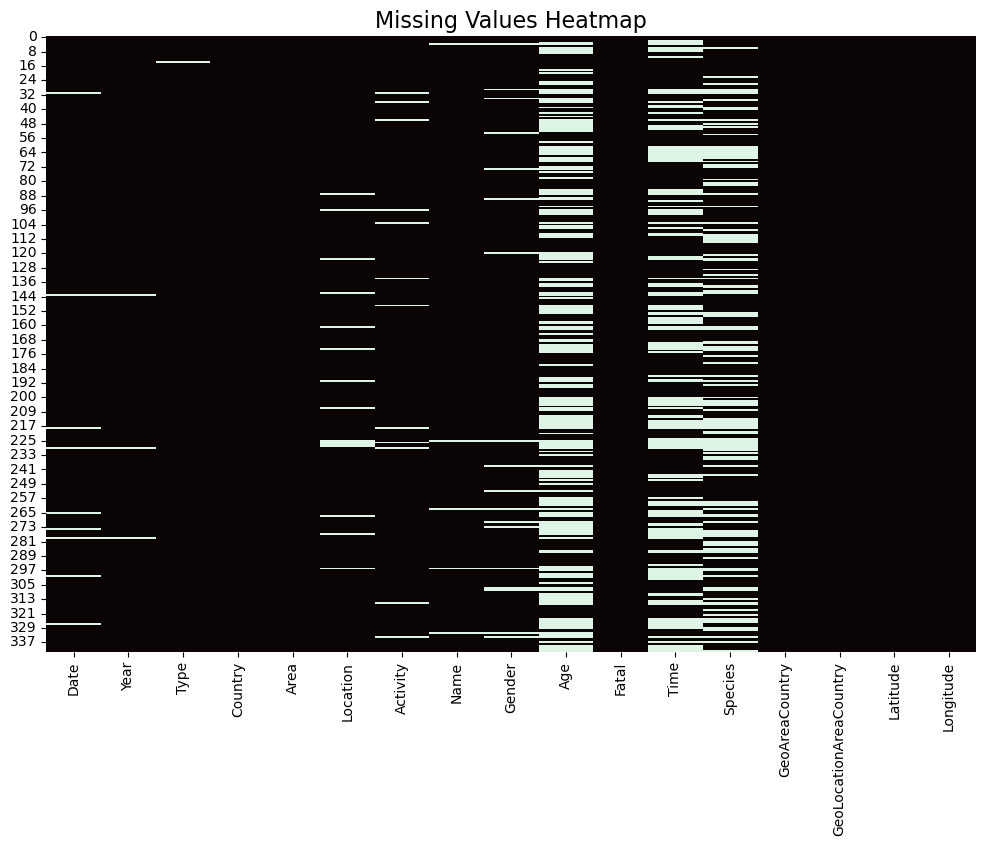

In [15]:
# Visualize missing values as a heatmap
# Source: https://medium.com/@HildaPosada/finding-and-visualizing-missing-data-in-python-using-missingno-and-seaborn-d4cf0452b9e9
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=palette_str)
plt.title('Missing Values Heatmap', fontsize=16)
plt.savefig('missing-values-heatmap.png', dpi=400)
plt.show()

In [16]:
"""
Cleaning Fatal

The Fatal data is binary either Yes or No.
"""
df["Fatal"] = df["Fatal"].replace("Y",1)
df["Fatal"] = df["Fatal"].replace("y",1)
df["Fatal"] = df["Fatal"].replace("F",1)
df["Fatal"] = df["Fatal"].replace("Y x 2",1)
df["Fatal"] = df["Fatal"].replace("N",0)
df["Fatal"] = df["Fatal"].replace("n",0)
df["Fatal"] = df["Fatal"].replace("Nq",0)  # A single record. Looked up name of victim. She survived.
df["Fatal"] = df["Fatal"].replace("2017.0",0) # Another single record. Looked up name and he survived.
df["Fatal"] = df["Fatal"].replace("UNKNOWN",None)

# Drop the more sparse NA (based on the missing values graph)
df.dropna(subset=["Fatal"], inplace=True)
df.dropna(subset=["Year"], inplace=True)


"""
Cleaning Date
"""
# Replace NaN with None
df["Date"] = df["Date"].replace("nan", None) 
df.dropna(subset=["Date"], inplace=True)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Save the Month as this is important. It can map to shark breeding behavior.
df["Month"] = df["Date"].dt.month_name()
df["Month"] = df["Month"].fillna("Unknown")
df["Month"].value_counts()

df["Day"] = df["Date"].dt.day
df["Day Of Year"] = df["Date"].dt.day_of_year
df["Day Name"] = df["Date"].dt.day_name()



"""
Cleaning Type
"""
df = df.drop(df[df["Type"] == "Invalid"].index) # Remove invalid record
df = df.drop(df[df["Type"] == "Questionable"].index) # Remove Questionable record
df["Type"] = df["Type"].replace("?","Unknown")
df["Type"] =  df["Type"].fillna("Unknown")
df["Type"] = df["Type"].astype(object)


"""
Cleaning Gender
"""
df["Gender"] = df["Gender"].replace("M x 2","M")
df["Gender"] = df["Gender"].replace("nan", "Unknown") 
df["Gender"] = df["Gender"].replace("N", "Unknown") 
df["Gender"] = df["Gender"].replace(".", "Unknown") 
df["Gender"] = df["Gender"].replace("lli", "Unknown")
df["Gender"] = df["Gender"].replace("", "Unknown")


df["Gender"] = df["Gender"].fillna("Unknown")
df["Gender"] = df["Gender"].astype(object)


"""
Cleaning Age
"""
def numeric_age(value):
    if not value:
        return None
    
    if value.isdigit():
        value = int(value)

    try:
        value = float(value)
    except ValueError:
        return None
    
    return value


# Everything else with NaN replace with None
df = df.applymap(lambda x: None if pd.isna(x) else x)

df["Age"] = df["Age"].map(numeric_age)
df["Age"] = df["Age"].fillna(df["Age"].median()) # Apply median to fill NA

"""
Cleaning Activity
"""
df["Activity"] =  df["Activity"].fillna("Unknown")
others = []

import re

def clean_activity_name(value):
    if not isinstance(value, str):
        others.append(value)
        return "Unknown"
    
    if re.search("spear", value.lower()):
        return "Spearfishing"
    elif re.search("(fishing|crabbing)", value.lower()):
        return "Fishing"
    elif re.search("(body surfing|body-surfing)", value.lower()):
        return "Body Surfing"
    elif re.search("(snorkeling|snorkling)", value.lower()):
        return "Snorkeling"
    elif re.search("(surf-skiing|surfskiing|surf skiing)", value.lower()):
        return "Surf-skiing"
    elif re.search("kayaking", value.lower()):
        return "Kayaking"
    elif re.search("filming", value.lower()):
        return "Filming"
    elif re.search("(surfing|body boarding|boogie|surf\s+board|surfboard|body-boarding)", value.lower()):
        return "Surfing"
    elif re.search("surf ski", value.lower()):
        return "Surf-skiing"
    elif re.search("(swim|treading)", value.lower()):
        return "Swimming"
    elif re.search("(diving|dived|dive)", value.lower()):
        return "Diving"
    elif re.search("(bathed|bathing)", value.lower()):
        return "Bathing"
    elif re.search("tsunami", value.lower()):
        return "Tsunami"
    elif re.search("outrigger", value.lower()):
        return "Outrigger"
    elif re.search("(kite\s+boarding|kite-boarding|kiteboarding)", value.lower()):
        return "Kite Boarding"
    elif re.search("(foil boarding|foil-boarding|kite foiling)", value.lower()):
        return "Foil Boarding"
    elif re.search("rowing", value.lower()):
        return "Rowing"
    elif re.search("floating", value.lower()):
        return "Floating"
    elif re.search("(sup|paddleboarding|paddleboard|paddle\s+boarding|paddle-boarding)", value.lower()):
        return "SUP"
    elif re.search("(wading|shallows|standing)", value.lower()):
        return "Wading"
    elif re.search("playing", value.lower()):
        return "Playing"
    elif re.search("paddling", value.lower()):
        return "Paddling"
    elif re.search("canoeing", value.lower()):
        return "Canoeing"
    elif re.search("fell", value.lower()):
        return "Fell"
    elif re.search("jumping", value.lower()):
        return "Jumping"
    elif re.search("walking", value.lower()):
        return "Walking"
    elif re.search("shark", value.lower()):
        return "Direct Contact"
    elif re.search("(boat accident|capsize|sunk|sink|sank|overboard|adrift|ship|explosion|destroyer|freighter|torpedo|shipwrecked|wrecked|wreck|swamped|founder|sea disaster|ship wreck)", value.lower()):
        return "Boat Accident"
    elif re.search("(airline|aircraft|crash|plane)", value.lower()):
        return "Air Accident"
    else:
        others.append(value)
        return value
        

df["Activity"] = df["Activity"].apply(lambda x: " ".join(x.split())) # strip extra whitespace from string
df["Activity"] = df["Activity"].map(clean_activity_name)
df["Activity"] = df["Activity"].astype(object)


"""
Cleaning Country
"""
df["Country"] = df["Country"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Country"] = df["Country"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())
df["Country"] = df["Country"].astype(object)


"""
Cleaning Area
"""
df["Area"] = df["Area"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Area"] = df["Area"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())
df["Area"] = df["Area"].astype(object)



"""
Location
"""
df["Location"] = df["Location"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Location"] = df["Location"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())



"""
Cleaning Species
"""
others = []
def clean_species(value):
    if not isinstance(value, str):
        others.append(value)
        return "Unknown"
    # Note: Order of conditional matters
    if re.search("sand", value.lower()):
        return "Sand Shark"
    elif re.search("(raggedtooth| ragged tooth)", value.lower()):
        return "Raggedtooth Shark"
    elif re.search("(bull|zambezi|zambesi|leucas)", value.lower()):
        return "Bull Shark"
    elif re.search("lemon", value.lower()):
        return "Lemon Shark"
    elif re.search("thresher", value.lower()):
        return "Thresher Shark"
    elif re.search("nurse", value.lower()):
        return "Nurse Shark"
    elif re.search("(hammerhead|hammer head)", value.lower()):
        return "Hammerhead Shark"
    elif re.search("(blacktip|black tip)", value.lower()):
        return "Blacktip Shark"
    elif re.search("(copper|bronze|whaler|narrowtooth)", value.lower()):
        return "Copper Shark"
    elif re.search("(whale|while shark)", value.lower()):
        return "Whale Shark"
    elif re.search("mako", value.lower()):
        return "Mako Shark"
    elif re.search("(leopard|leapord)", value.lower()):
        return "Leopard Shark"
    elif re.search("blue", value.lower()):
        return "Blue Shark"
    elif re.search("spinner", value.lower()):
        return "Spinner Shark"
    elif re.search("wobbegong", value.lower()):
        return "Wobbegong Shark"
    elif re.search("carpet", value.lower()):
        return "Carpet Shark"
    elif re.search("reef", value.lower()):
        return "Reef Shark" 
    elif re.search("(dusky|c. obscurus|carcharhinus obscurus)", value.lower()):
        return "Dusky Shark"   
    elif re.search("angel", value.lower()):
        return "Angel Shark" 
    elif re.search("shovelnose", value.lower()):
        return "Shovelnose Shark" 
    elif re.search("sharpnose", value.lower()):
        return "Sharpnose Shark" 
    elif re.search("(sevengill|seven-gill|seven gill)", value.lower()):
        return "Sevengill Shark"
    elif re.search("(galapagos|galapagensis)", value.lower()):
        return "Galapagos Shark"
    elif re.search("(grey|gray|Carcharhinus)", value.lower()):
        return "Gray Shark"
    elif re.search("(whitetip| white tip)", value.lower()):
        return "Whitetip Shark"
    elif re.search("(white|great)", value.lower()):
        return "White Shark"
    elif re.search("tiger", value.lower()):
        return "Tiger Shark"
    else:
        others.append(value)
        return value


df["Species"] = df["Species"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Species"] = df["Species"].map(clean_species)
df["Species"] = df["Species"].astype(object)
df["Species"] = df["Species"].apply(lambda x: "Unknown" if pd.isna(x) else x)


# Leaving Species N/A as Unknown because there should be a correlation between fatality and no report / sighting of species
"""
Cleaning Longitude
"""
df = df.drop(df[df["Longitude"] > -150].index) 


In [17]:
df.shape

(237, 21)

In [18]:
"""
Create the Geohashes
"""
# Convert the geo data to a GeoDataFrame
# EPSG:4326 is the widely used code for the WGS 84 geographic coordinate system
loc_crs = {'init': 'epsg:4326'}
loc_geom = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
geo_df = gpd.GeoDataFrame(df, crs=loc_crs, geometry=loc_geom)

# Geohash can determine proximity but fails if point is across geohash grid boundary
# Points near 180 degress meridian may have very different Geohashes
# Precision decreases near the polls
# Cells have different physical areas at different latitudes

"""
Geohash precision:
1   5,009.4km x 4,992.6km
2   1,252.3km x 624.1km
3   156.5km x 156km
4   39.1km x 19.5km
5   4.9km x 4.9km
6   1.2km x 609.4m
7   152.9m x 152.4m
8   38.2m x 19m
9   4.8m x 4.8m
10  1.2m x 59.5cm
11  14.9cm x 14.9cm
12  3.7cm x 1.9cm 
"""
# Precision 8 yielded best initial scores
# But we can use Geohashes to create a sort of bounding box of different sizes
geo_df['Geohash P4'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=4), axis=1)
geo_df['Geohash P5'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=5), axis=1)
geo_df['Geohash P6'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=6), axis=1)
geo_df['Geohash P7'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=7), axis=1)
geo_df['Geohash P8'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=8), axis=1)
geo_df['Geohash P9'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=9), axis=1)


geo_df.head()

,Date,Year,Type,Country,Area,Location,Activity,Name,Gender,Age,Fatal,Time,Species,GeoAreaCountry,GeoLocationAreaCountry,Latitude,Longitude,Month,Day,Day Of Year,Day Name,geometry,Geohash P4,Geohash P5,Geohash P6,Geohash P7,Geohash P8,Geohash P9
0,2015-10-09,2015.0,Unprovoked,USA,HAWAII,"LEFTOVERS, OAHU",Surfing,Colin Cook,M,25.0,0,10h25,Tiger Shark,"Hawaii, USA","Leftovers, Oahu, Hawaii, USA",21.485000,-157.965000,October,9,282,Friday,POINT (-157.965 21.485),87zd,87zdj,87zdjr,87zdjrj,87zdjrjr,87zdjrjrh
1,2013-06-18,2013.0,Unprovoked,USA,HAWAII,KONA COAST STATE PARK,Swimming,James Kerrigan,M,28.0,0,12h50,Tiger Shark,"Hawaii, USA","Kona Coast State Park, Hawaii, USA",21.345088,-158.039205,June,18,169,Tuesday,POINT (-158.0392 21.34509),87z9,87z97,87z97t,87z97tz,87z97tz2,87z97tz25
3,1993-12-01,1993.0,Unprovoked,USA,HAWAII,WAIPO,Surfing,Daniel McMoyler,M,36.0,1,None,Tiger Shark,"Hawaii, USA","Waipo, Hawaii, USA",20.113404,-155.593200,December,1,335,Wednesday,POINT (-155.5932 20.1134),8e96,8e967,8e967m,8e967ms,8e967ms3,8e967ms3p
4,1993-10-01,1993.0,Unprovoked,USA,HAWAII,"MOUTH OF WALLUA RIVER, KAUA'I",Surfing,None,Unknown,36.0,0,None,Tiger Shark,"Hawaii, USA","Mouth of Wallua River, Kaua'i, Hawaii, USA",22.070000,-159.497500,October,1,274,Friday,POINT (-159.4975 22.07),87yt,87ytd,87ytd9,87ytd99,87ytd99r,87ytd99rn
5,1990-10-15,1990.0,Unprovoked,USA,HAWAII,"HANALEI POINT, KAUA'I",Surfing,Greg Filtzer,M,43.0,0,15h00,Tiger Shark,"Hawaii, USA","Hanalei Point, Kaua'i, Hawaii, USA",22.203169,-159.495670,October,15,288,Monday,POINT (-159.49567 22.20317),87yw,87yw6,87yw69,87yw69f,87yw69fy,87yw69fyc


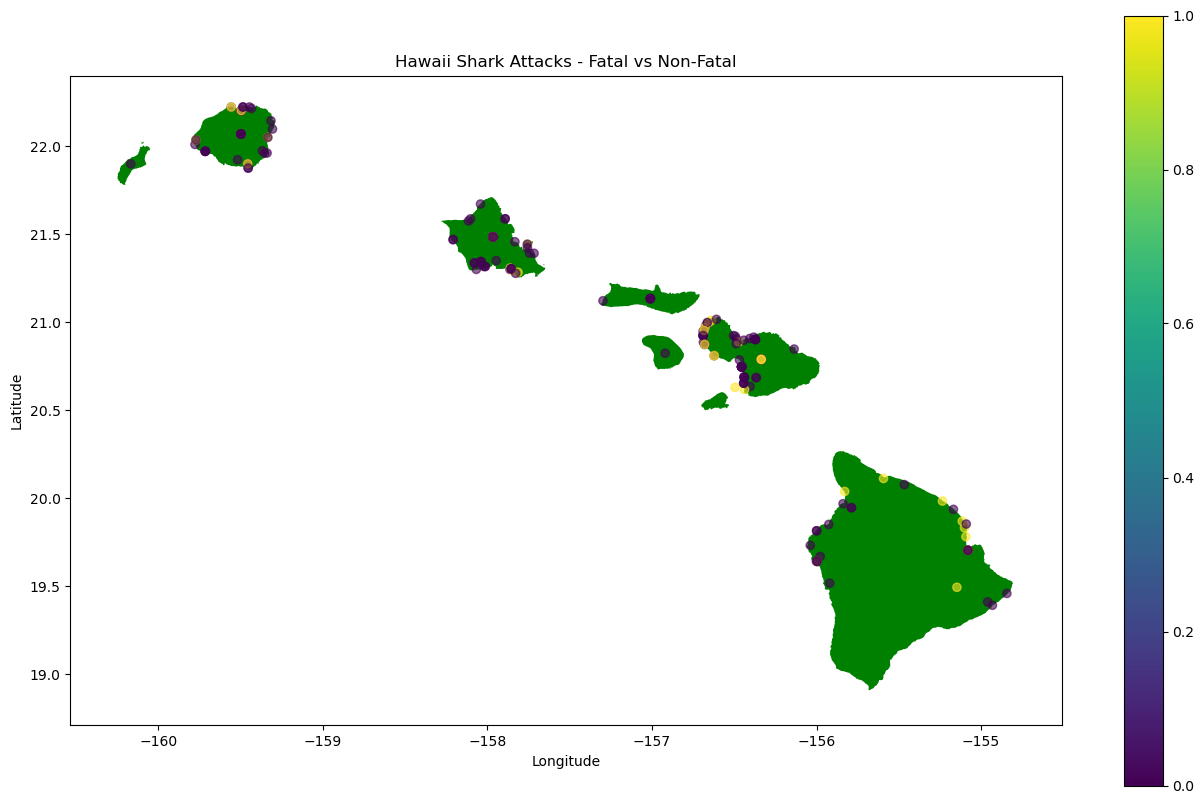

In [140]:
"""
Plot the Geo Points
"""
worldmap = gpd.read_file("hawaii.geojson")
fig, ax = plt.subplots(figsize=(16, 10))

x_min_new = worldmap.bounds['minx'].min() + 17.8 # subtract padding
x_max_new = worldmap.bounds['maxx'].max() + .3 # add padding
y_min_new = worldmap.bounds['miny'].min() - 0.2
y_max_new = worldmap.bounds['maxy'].max() - 6

ax.set_xlim([x_min_new, x_max_new])
ax.set_ylim([y_min_new, y_max_new])

worldmap.plot(color="green", aspect=1, ax=ax, legend=True)

geo_points = geo_df[["Fatal", "geometry"]].copy(deep=True)

geo_points.plot(ax=ax, column='Fatal',  legend=True, alpha=0.6)




plt.title("Hawaii Shark Attacks - Fatal vs Non-Fatal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig('global-map.png', dpi=400, bbox_inches='tight') 
plt.show()

In [20]:
def truncator(value):
    return value[0:30]

Location
WAILEA BEACH, MAUI                                               2
KAHULUI, MAUI                                                    2
PAIA BAY, MAUI                                                   2
HO'OKIPA BEACH, PA'IA, MAUI                                      2
MAILE BEACH, O'AHU                                               2
MAUI                                                             2
LOWER PAIA BEACH PARK, MAUI                                      1
MAHA'ULEPU, KOLOA, KAUA'I                                        1
BRENECKE BEACH, PO'IPU, KAUA'I                                   1
MAKUA BEACH, OAHU                                                1
MOLOKAI CHANNEL/                                                 1
CHARLIE YOUNG BEACH, KIHEI, MAUI                                 1
MAKAHA                                                           1
KALIHI, O'AHU                                                    1
BETWEEN ALA MOANA CHANNEL & KEWALO BASIN, O'AHU      

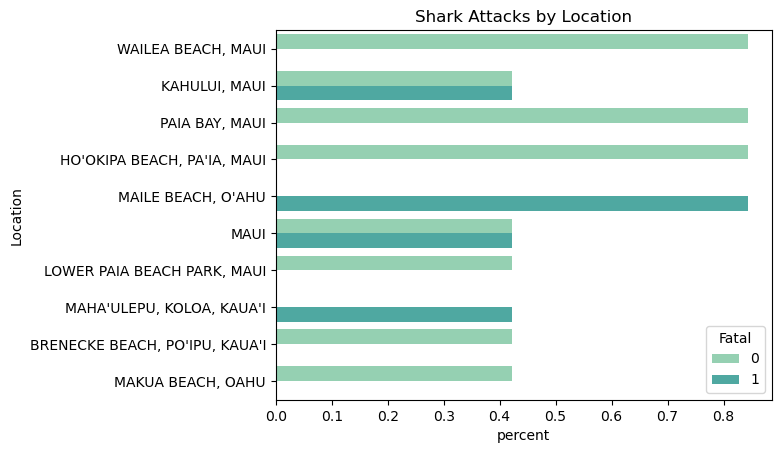

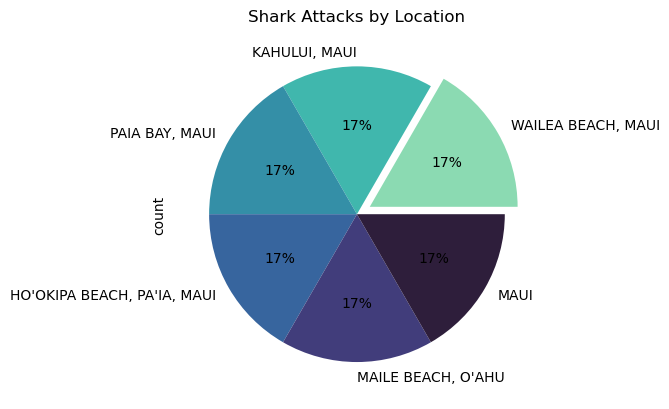

In [21]:
"""
By Location
"""
print(geo_df["Location"].value_counts().iloc[:40])

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Location", 
              data=geo_df, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=geo_df["Location"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Location")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
geo_df["Location"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Location") 
plt.savefig('attacks-by-location.png', dpi=400) 
plt.show()

Activity
Surfing                                   85
Swimming                                  39
Fishing                                   23
Snorkeling                                20
Diving                                    11
Spearfishing                              10
SUP                                        9
Direct Contact                             6
Boat Accident                              4
Floating                                   4
Wading                                     3
Body Surfing                               3
Kayaking                                   3
Air Accident                               2
Canoeing                                   2
Kite Boarding                              2
Foil Boarding                              2
Fell                                       1
Gathering fish stunned by dynamite         1
Catching crabs                             1
Hunting turtle                             1
Resting on body board                      1
J

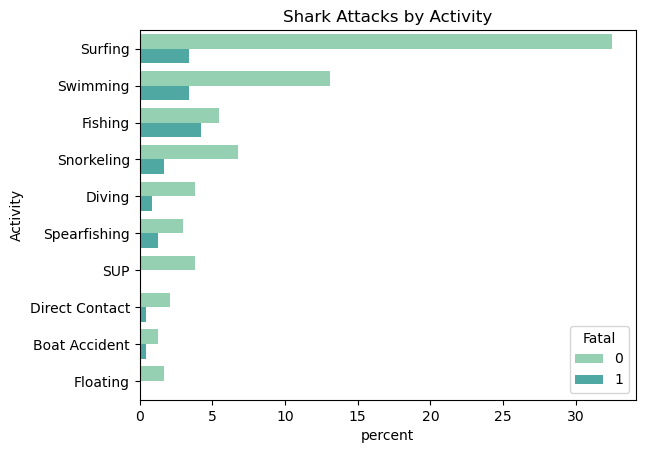

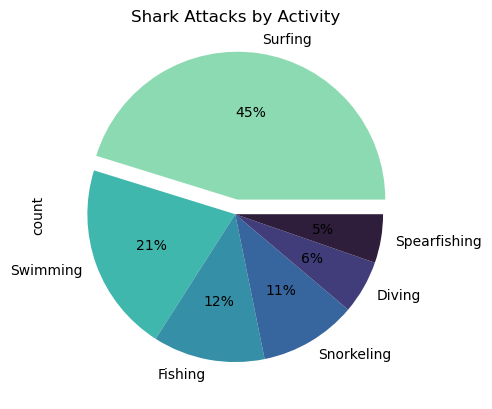

In [22]:
"""
By Activity
"""
print(geo_df["Activity"].value_counts().iloc[:40])

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Activity", 
              data=geo_df, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=geo_df["Activity"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Activity")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
geo_df["Activity"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Activity") 
plt.savefig('attacks-by-activity.png', dpi=400) 
plt.show()

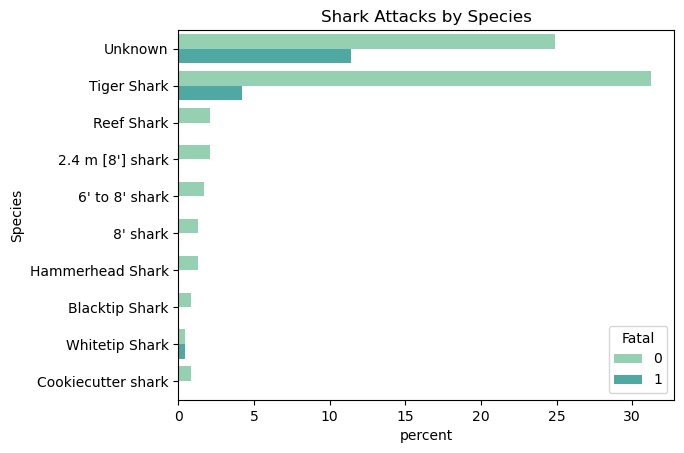

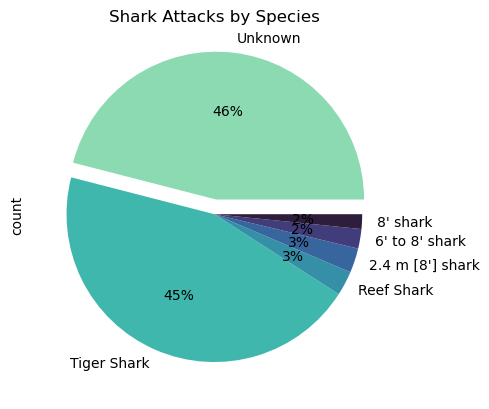

In [23]:
"""
By Species
"""

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Species", 
              data=geo_df, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=geo_df["Species"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Species")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
geo_df["Species"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Species") 
plt.savefig('attacks-by-species.png', dpi=400) 
plt.show()

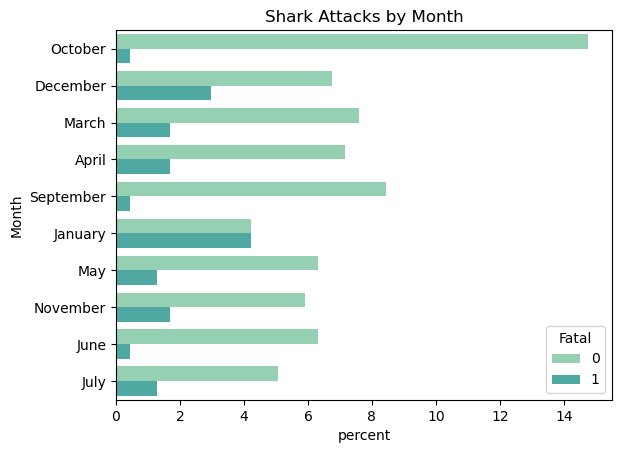

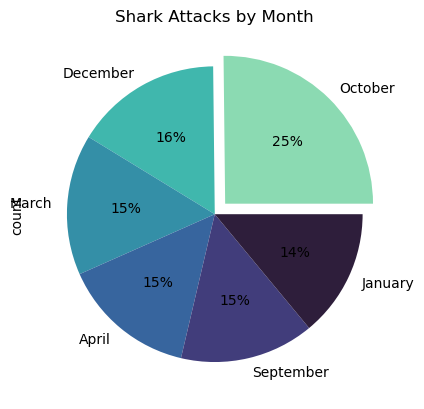

In [24]:
"""
By Month
"""

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Month", 
              data=geo_df, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=geo_df["Month"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Month")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
geo_df["Month"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Month") 
plt.savefig('attacks-by-month.png', dpi=400) 
plt.show()

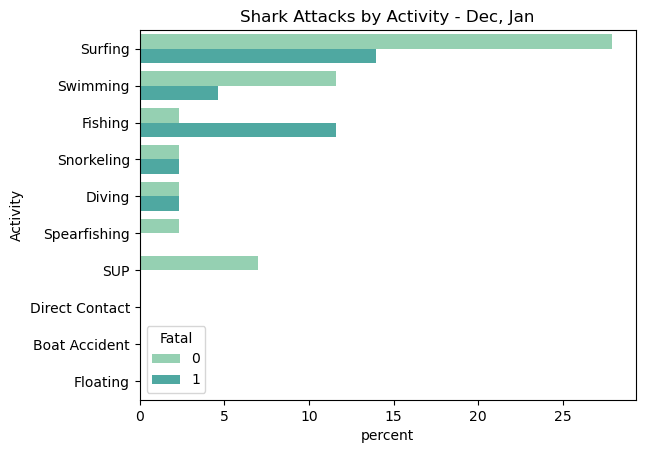

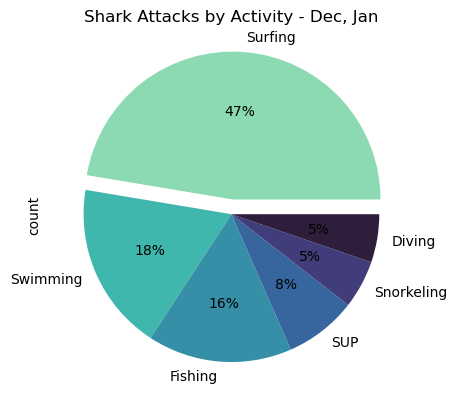

In [25]:
"""
Zoom in on Dec, Jan
Highest fatalities
"""
dec_jan =  geo_df[(geo_df["Month"] == "December") | (geo_df["Month"] == "January")]

"""
By Activity
"""

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Activity", 
              data=dec_jan, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=geo_df["Activity"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Activity - Dec, Jan")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
dec_jan["Activity"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Activity - Dec, Jan") 
plt.savefig('attacks-by-activity-dec-jan.png', dpi=400) 
plt.show()

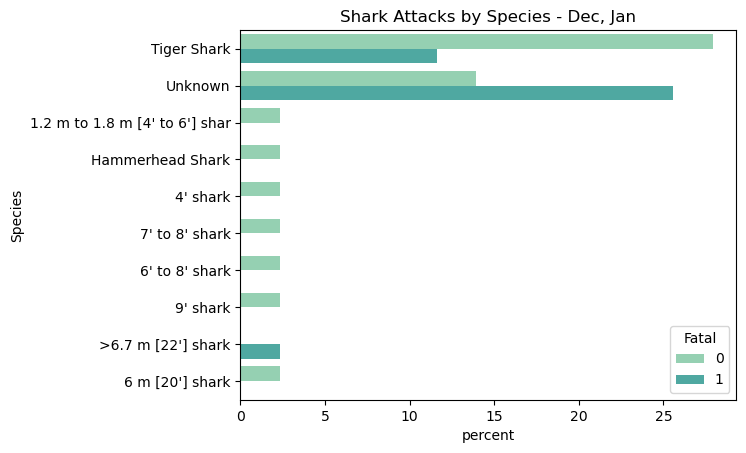

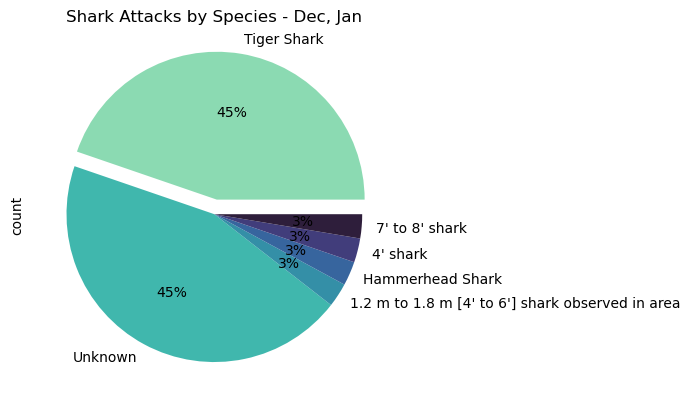

In [26]:
"""
Zoom in on Dec, Jan
Highest fatalities
"""


"""
By Species
"""

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Species", 
              data=dec_jan, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=dec_jan["Species"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Species - Dec, Jan")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
dec_jan["Species"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Species - Dec, Jan") 
plt.savefig('attacks-by-species-dec-jan.png', dpi=400) 
plt.show()

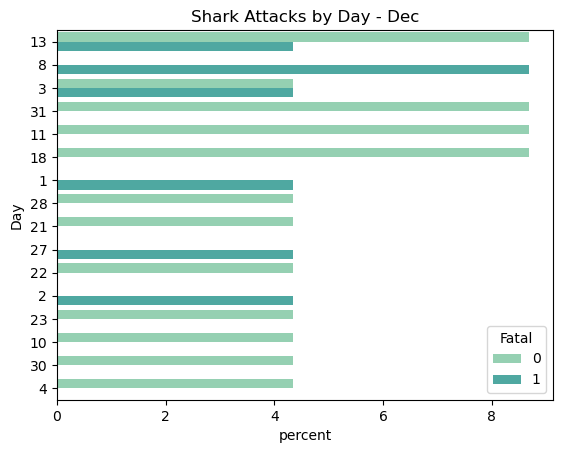

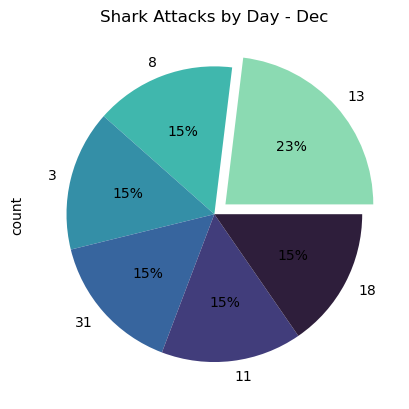

In [27]:
"""
Zoom in on Dec
Highest fatalities
"""
dec =  geo_df[(geo_df["Month"] == "December")]

"""
By Day
"""

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Day", 
              data=dec, 
              hue="Fatal", 
              stat="percent", 
              order=dec["Day"].value_counts().iloc[:20].index)
plt.title("Shark Attacks by Day - Dec")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
dec["Day"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Day - Dec") 
plt.savefig('attacks-by-day-dec.png', dpi=400) 
plt.show()

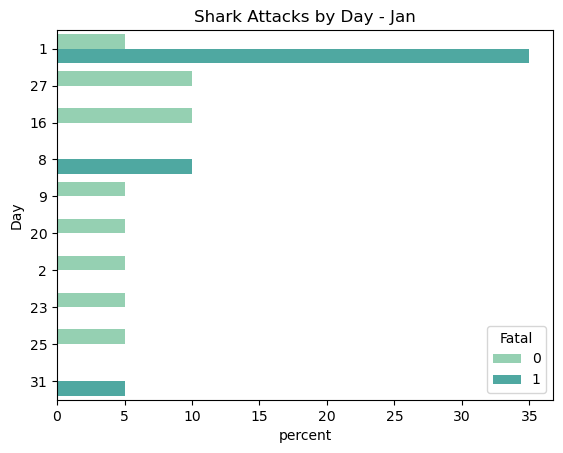

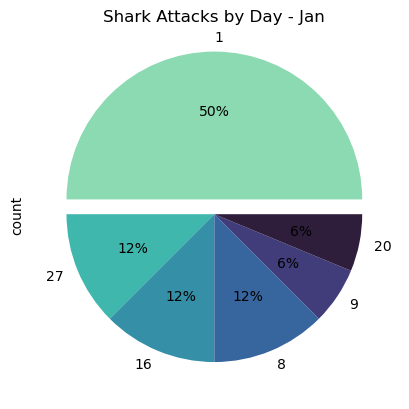

In [28]:
"""
Zoom in on Jan
Highest fatalities
"""
jan =  geo_df[(geo_df["Month"] == "January")]

"""
By Day
"""

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Day", 
              data=jan, 
              hue="Fatal", 
              stat="percent", 
              order=jan["Day"].value_counts().iloc[:10].index)
plt.title("Shark Attacks by Day - Jan")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
jan["Day"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Day - Jan") 
plt.savefig('attacks-by-day-jan.png', dpi=400) 
plt.show()

Day Of Year
1      8
207    4
301    4
347    3
Name: count, dtype: int64


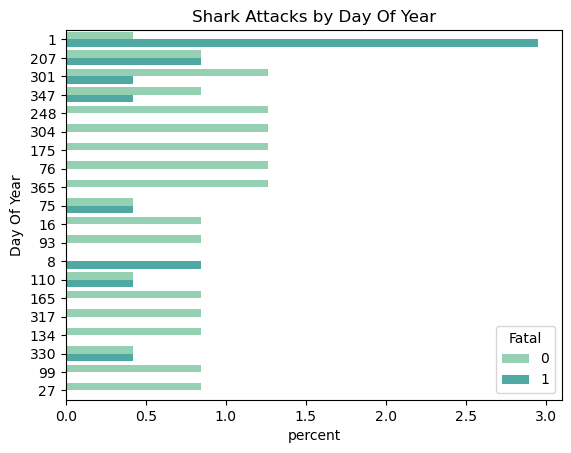

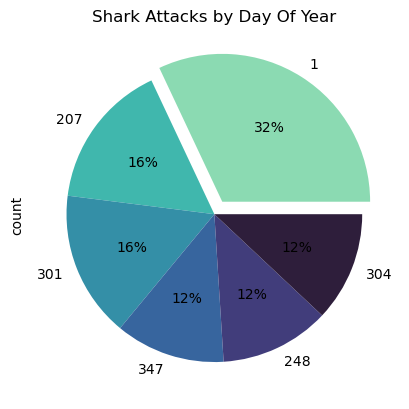

In [29]:
"""
Day of Year
"""
print(geo_df["Day Of Year"].value_counts().iloc[:4])

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Day Of Year", 
              data=geo_df, 
              hue="Fatal", 
              stat="percent", 
              order=geo_df["Day Of Year"].value_counts().iloc[:20].index)
plt.title("Shark Attacks by Day Of Year")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
geo_df["Day Of Year"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Day Of Year") 
plt.savefig('attacks-by-day-of-year.png', dpi=400) 
plt.show()

Species
Unknown        7
Tiger Shark    1
Name: count, dtype: int64


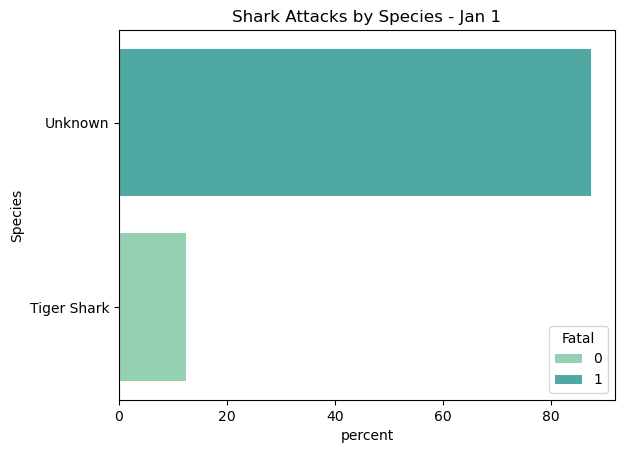

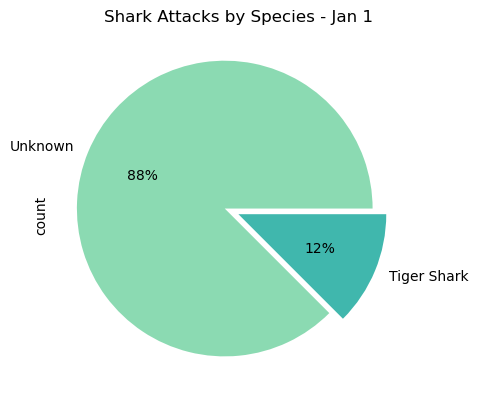

In [30]:
"""
Zoom in on Jan 1
"""
day1 =  geo_df[(geo_df["Day Of Year"] == 1)]

"""
By Species
"""
print(day1["Species"].value_counts().iloc[:4])

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Species", 
              data=day1, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=day1["Species"].value_counts().iloc[:3].index)
plt.title("Shark Attacks by Species - Jan 1")
plt.show()

"""
Pie
"""
explode = [0.1, 0] 

day1["Species"].value_counts().iloc[:3].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Species - Jan 1") 
plt.savefig('attacks-by-species-jan1.png', dpi=400) 
plt.show()

Activity
Surfing         3
Fishing         2
Air Accident    1
Diving          1
Swimming        1
Name: count, dtype: int64


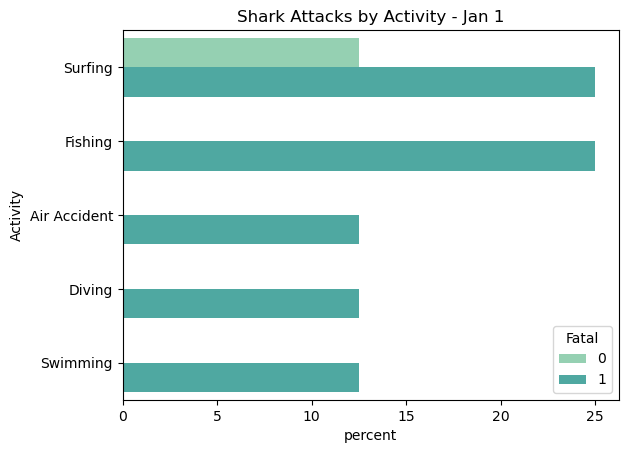

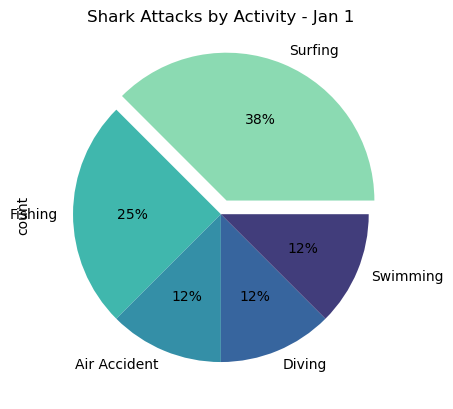

In [31]:
"""
Zoom in on Jan 1
"""

"""
By Activity
"""
print(day1["Activity"].value_counts().iloc[:6])

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Activity", 
              data=day1, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=day1["Activity"].value_counts().iloc[:6].index)
plt.title("Shark Attacks by Activity - Jan 1")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0] 

day1["Activity"].value_counts().iloc[:5].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Activity - Jan 1") 
plt.savefig('attacks-by-activity-jan1.png', dpi=400) 
plt.show()

Location
MAUI                                 1
SOUTH KOHALA, HAWAI'I                1
PEPE'EKEO, HONOMU, HAWAI'I           1
MAJORS BAY, KAUA'I                   1
OFF LAHAINA, MAUI                    1
OFF DIAMOND HEAD, HONOLULU, O'AHU    1
MALIU, HAWAI'I                       1
Name: count, dtype: int64


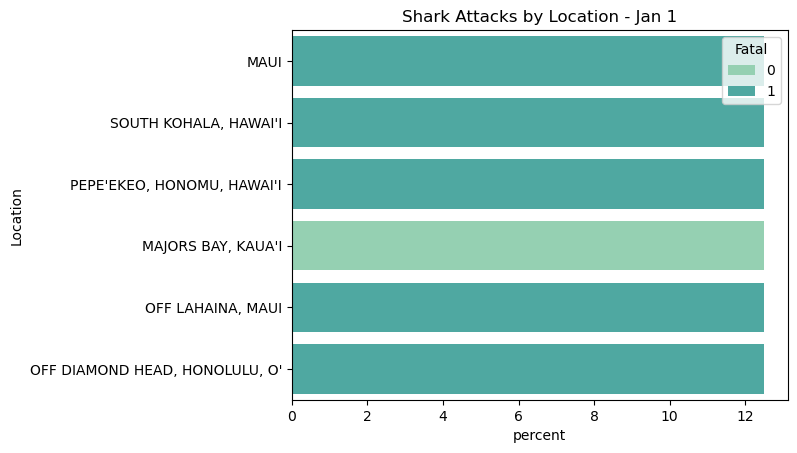

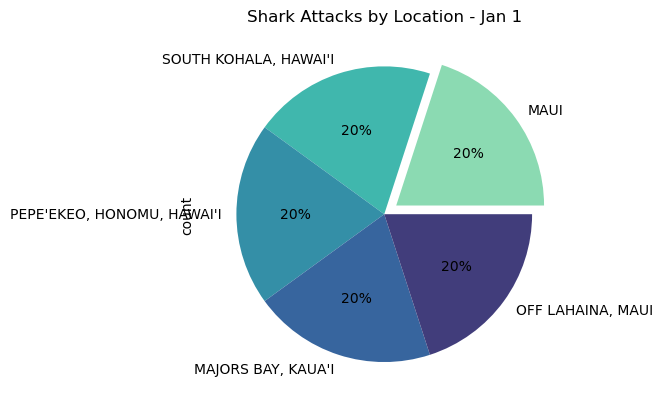

In [32]:
"""
Zoom in on Jan 1
"""

"""
By Location
"""
print(day1["Location"].value_counts().iloc[:7])
""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Location", 
              data=day1, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=day1["Location"].value_counts().iloc[:6].index)
plt.title("Shark Attacks by Location - Jan 1")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0] 

day1["Location"].value_counts().iloc[:5].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Location - Jan 1") 
plt.savefig('attacks-by-location-jan1.png', dpi=400) 
plt.show()

Day Name
Wednesday    42
Tuesday      39
Sunday       38
Monday       31
Friday       29
Saturday     29
Name: count, dtype: int64


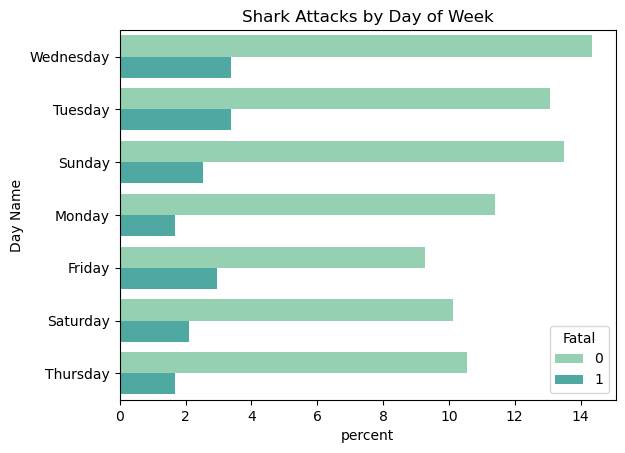

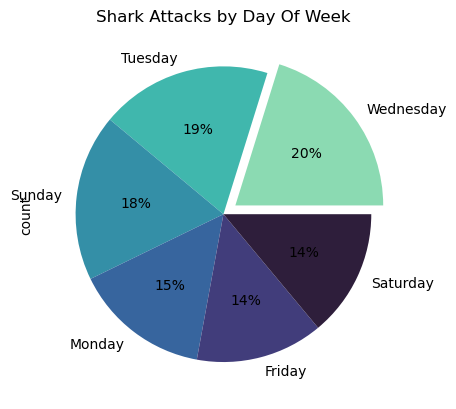

In [33]:
"""
Day Name - Day of Week
"""
print(geo_df["Day Name"].value_counts().iloc[:6])

""" 
Bar 
"""
sns.set_palette(palette_r)
sns.countplot(y="Day Name", 
              data=geo_df, 
              hue="Fatal", 
              stat="percent", 
              order=geo_df["Day Name"].value_counts().iloc[:20].index)
plt.title("Shark Attacks by Day of Week")
plt.show()

"""
Pie
"""
explode = [0.1, 0, 0, 0, 0, 0] 
geo_df["Day Name"].value_counts().iloc[:6].plot.pie(legend=False,
                                             colors=sns.color_palette(palette_str_r),
                                             explode=explode,
                                             autopct="%1.0f%%")
plt.title("Shark Attacks by Day Of Week") 
plt.savefig('attacks-by-day-of-week.png', dpi=400) 
plt.show()